# Speech / Silence Segmentation — Short-Time Energy with Gaussian Threshold

**Author:** `<Nguyễn Hoàng Hiếu>` (ID `<102240135>`)

**Goal.** Split a speech recording into *speech* and *silence* segments and measure how close the detected boundaries are to the ground-truth labels (`.lab` files). The decision threshold on the short-time energy is learned automatically from a training set by modelling the two classes with Gaussian distributions.

### Notebook outline

| # | Section | Content |
|---|---------|---------|
| 1 | Setup | imports, global parameters |
| 2 | Data I/O | read `.wav` signals and `.lab` annotations, frame labels |
| 3 | Feature extraction | framing, short-time energy (STE) |
| 4 | Gaussian threshold | two Gaussians → intersection → threshold |
| 5 | Segmentation | post-processing, boundaries |
| 6 | Evaluation | boundary errors (MAE / RMSE), per-boundary diagnostics |
| 7 | Visualization | training distributions, per-file result plot |
| 8 | Train / test routines | training, testing and summary routines |
| 9 | Run | train → distribution figure → test → summary table |

### Method at a glance
1. Cut each signal into 25 ms frames every 10 ms (Hamming window); compute the **STE** of every frame and normalize it to $[0, 1]$.
2. **Training:** collect the STE values of speech frames and silence frames, fit one Gaussian to each class and take the intersection of the two Gaussians as the decision threshold.
3. **Testing:** a frame is *speech* if its STE is above the threshold; the decision is smoothed (isolated speech frames removed, silences shorter than 200 ms filled).
4. Extract the speech boundaries from the 0/1 transitions and compare them with the ground truth using MAE and RMSE.

## 1. Setup

### 1.1 Imports
Standard library, NumPy for numerics and Matplotlib for plots.

In [1]:
# ---- Standard library ----
import os
import wave

# ---- Scientific stack ----
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Show figures inline so that they are stored in the notebook
%matplotlib inline

### 1.2 Global parameters
All tunable constants live here.

In [2]:
# =====================================================================
# GLOBAL PARAMETERS
# =====================================================================

# --- Framing ---
FRAME_LEN_MS = 25       # frame length (ms)
FRAME_SHIFT_MS = 10     # frame shift / hop size (ms)
MIN_SILENCE_MS = 200    # silences shorter than this (between two speech parts) are filled

# --- Data folders ---
TRAIN_DIR = 'TinHieuHuanLuyen'   # folder with training .wav + .lab files
TEST_DIR = 'TinHieuKiemThu'      # folder with test .wav + .lab files

## 2. Data I/O
Helpers to read a `.wav` signal (mono, normalized to $[-1, 1]$), read the ground-truth intervals from the matching `.lab` file and convert a time stamp into a speech / silence label.

In [3]:
def read_audio(path):
    """Read a 16-bit PCM .wav file and normalize it to [-1, 1].

    Args:
        path (str): Path to the `.wav` file.

    Returns:
        tuple[np.ndarray, int, np.ndarray]: `(signal, fs, t_sig)` — samples scaled to
        [-1, 1], sampling rate in Hz and the time axis in seconds (one value per sample).
    """
    # Open the file and read the header information and the raw bytes
    with wave.open(path, 'rb') as wav_file:
        fs = wav_file.getframerate()               # samples per second
        n_samples = wav_file.getnframes()          # total number of samples
        raw = wav_file.readframes(n_samples)       # raw bytes of all samples

    # Convert the bytes to 16-bit integers (standard .wav format)
    signal = np.frombuffer(raw, dtype=np.int16)

    # Normalize the amplitude to [-1, 1]; an all-zero file is kept unchanged
    max_amp = np.max(np.abs(signal))
    signal = signal / max_amp if max_amp > 0 else signal.astype(float)

    # Build the time axis in seconds
    t_sig = np.linspace(0, n_samples / fs, num=n_samples)
    return signal, fs, t_sig


def read_lab_file(lab_path):
    """Read a `.lab` file and return its labelled time intervals.

    Lines such as `F0mean` / `F0std` are ignored.

    Args:
        lab_path (str): Path to the `.lab` file (lines of `start end label`).

    Returns:
        list[tuple[float, float, str]]: Intervals `(start_s, end_s, label)`; times in seconds.
    """
    intervals = []
    with open(lab_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            # Keep only "start end label" lines and skip the F0 statistics lines
            if len(parts) == 3 and parts[0] not in ['F0mean', 'F0std']:
                intervals.append((float(parts[0]), float(parts[1]), parts[2]))
    return intervals


def get_frame_label(time_sec, intervals):
    """Give a frame its ground-truth label from the `.lab` intervals.

    Args:
        time_sec (float): Start time of the frame in seconds.
        intervals (list[tuple]): Output of `read_lab_file`.

    Returns:
        int: 0 for silence (label `sil` or no interval found), 1 for speech (voiced or unvoiced).
    """
    for start, end, label in intervals:
        if start <= time_sec <= end:
            return 0 if label == 'sil' else 1
    return 0

## 3. Feature extraction
Each frame is multiplied by a Hamming window $w[n]$ of length $N$ and described by its **short-time energy**, divided by its maximum over the file so that it lies in $[0, 1]$:

$$STE = \sum_n x_w^2[n]$$

STE is high for speech and low for silence, so it is the only feature used for the decision.

In [ ]:
def extract_features(signal, fs):
    # Convert frame length / shift from milliseconds to samples
    frame_len = int(fs * FRAME_LEN_MS / 1000)
    frame_shift = int(fs * FRAME_SHIFT_MS / 1000)
    num_frames = int(np.ceil(len(signal) / frame_shift))

    # Allocate the outputs and the Hamming window used for every frame
    ste = np.zeros(num_frames)
    times = np.zeros(num_frames)
    window = np.hamming(frame_len)

    for i in range(num_frames):
        # Cut the i-th frame; zero-pad the last frame if it is too short
        start_idx = i * frame_shift
        frame = signal[start_idx:start_idx + frame_len]
        if len(frame) < frame_len:
            frame = np.pad(frame, (0, frame_len - len(frame)), 'constant')

        # Apply the window, then compute STE and the frame start time
        frame = frame * window
        ste[i] = np.sum(frame ** 2)
        times[i] = start_idx / fs

    # Normalize by the maximum so that STE is comparable between files
    if np.max(ste) > 0:
        ste = ste / np.max(ste)
    return ste, times

## 4. Gaussian threshold
The training STE values of silence frames $\mathcal N(\mu_1,\sigma_1^2)$ and speech frames $\mathcal N(\mu_2,\sigma_2^2)$ are modelled by Gaussians. Setting the two densities equal gives a quadratic equation $ax^2+bx+c=0$; the root lying between the two means is the threshold $T$.

In [5]:
def find_intersection(mu1, std1, mu2, std2):
    """Find the decision threshold where two Gaussian densities are equal.

    Args:
        mu1 (float): Mean of the first class (silence).
        std1 (float): Standard deviation of the first class.
        mu2 (float): Mean of the second class (speech).
        std2 (float): Standard deviation of the second class.

    Returns:
        float: The intersection point lying between the two means (the first root if none does).
    """
    # Coefficients of a*x^2 + b*x + c = 0 obtained from N(mu1, std1) = N(mu2, std2)
    a = 1.0 / (2 * std1 ** 2) - 1.0 / (2 * std2 ** 2)
    b = mu2 / (std2 ** 2) - mu1 / (std1 ** 2)
    c = mu1 ** 2 / (2 * std1 ** 2) - mu2 ** 2 / (2 * std2 ** 2) - np.log(std2 / std1)

    # Pick the root that separates the two classes (lies between the means)
    roots = np.roots([a, b, c])
    for root in roots:
        if min(mu1, mu2) <= root <= max(mu1, mu2):
            return root
    return roots[0]

## 5. Segmentation
Turn the frame-level STE into speech boundaries (in seconds):

1. **Classify** each frame: speech if `STE > threshold`.
2. **Remove** isolated single speech frames (pattern 0-1-0).
3. **Fill** silence gaps shorter than `MIN_SILENCE_MS` (they become speech).
4. **Convert** the 0/1 transitions into boundary times.

### 5.1 Post-processing of the frame decisions

In [6]:
def smooth_boundaries(flags, min_sil_frames):
    """Remove spurious very short speech and silence segments.

    Args:
        flags (np.ndarray): Raw per-frame decision (1 = speech, 0 = silence).
        min_sil_frames (int): Minimum number of consecutive silence frames that is kept as silence.

    Returns:
        np.ndarray: Smoothed per-frame decision of the same length.
    """
    smoothed = flags.copy()

    # Rule 1: delete isolated speech frames surrounded by silence
    for i in range(1, len(smoothed) - 1):
        if smoothed[i - 1] == 0 and smoothed[i] == 1 and smoothed[i + 1] == 0:
            smoothed[i] = 0

    # Rule 2: scan the sequence and fill silence runs shorter than the minimum
    zero_count, zero_start = 0, -1
    for i in range(len(smoothed)):
        if smoothed[i] == 0:
            if zero_count == 0:
                zero_start = i          # a new silence run starts here
            zero_count += 1
        else:
            if 0 < zero_count < min_sil_frames:
                smoothed[zero_start:i] = 1
            zero_count = 0

    # The last run may end at the end of the file
    if 0 < zero_count < min_sil_frames:
        smoothed[zero_start:] = 1
    return smoothed

### 5.2 Boundaries from decisions and from labels
Predicted boundaries come from the 0/1 transitions of the smoothed decision; ground-truth boundaries come from the `.lab` intervals (voiced and unvoiced labels are merged into one continuous speech segment).

In [7]:
def get_predicted_boundaries(flags, times):
    """Convert a 0/1 decision sequence into boundary time stamps.

    Args:
        flags (np.ndarray): Per-frame decision (1 = speech).
        times (np.ndarray): Start time of each frame in seconds.

    Returns:
        list[float]: Alternating speech start / speech end times in seconds.
    """
    # A change 0->1 (+1) or 1->0 (-1) marks a boundary
    diff = np.diff(np.insert(flags, 0, 0))
    bounds = [times[i] for i, d in enumerate(diff) if d == 1 or d == -1]

    # If the file ends during speech, close the last segment at the final frame
    if flags[-1] == 1:
        bounds.append(times[-1])
    return bounds


def get_true_speech_boundaries(intervals):
    """Get the ground-truth speech boundaries from the `.lab` intervals.

    Voiced and unvoiced labels are merged into one continuous speech segment.

    Args:
        intervals (list[tuple]): Output of `read_lab_file`.

    Returns:
        list[float]: Alternating speech start / speech end times in seconds.
    """
    bounds = []
    is_speech = False
    for start, end, label in intervals:
        if label != 'sil':
            if not is_speech:
                bounds.append(start)      # speech starts
                is_speech = True
        elif is_speech:
            bounds.append(start)          # speech ends where silence begins
            is_speech = False

    # If the file ends in speech, close it at the end of the last interval
    if is_speech:
        bounds.append(intervals[-1][1])
    return bounds

## 6. Evaluation
For every ground-truth boundary the nearest predicted boundary is found; the absolute time differences $e_k$ (ms) give

$$MAE = \frac{1}{K}\sum_k |e_k|, \qquad RMSE = \sqrt{\frac{1}{K}\sum_k e_k^2}$$

`boundary_diagnostics` additionally prints the *signed* error of each boundary (positive = prediction later than the truth) to help writing the figure comments.

In [8]:
def calculate_errors(true_bounds, pred_bounds):
    """Compute MAE and RMSE between true and predicted boundaries.

    Args:
        true_bounds (list[float]): Ground-truth boundary times in seconds.
        pred_bounds (list[float]): Predicted boundary times in seconds.

    Returns:
        tuple[float, float]: `(mae, rmse)` in milliseconds; `(0.0, 0.0)` if either list is empty.
    """
    if not true_bounds or not pred_bounds:
        return 0.0, 0.0

    # Nearest-neighbour matching: each true boundary is paired with the closest prediction
    errors = np.array([min(abs(pb - tb) for pb in pred_bounds) * 1000 for tb in true_bounds])
    return np.mean(errors), np.sqrt(np.mean(errors ** 2))


def boundary_diagnostics(true_bounds, pred_bounds, tol_ms=50):
    """Print a per-boundary error report to help writing the figure comments.

    Args:
        true_bounds (list[float]): Ground-truth boundary times in seconds.
        pred_bounds (list[float]): Predicted boundary times in seconds.
        tol_ms (float): Errors larger than this value (ms) are flagged as `LARGE`.

    Returns:
        None: The report is printed.
    """
    # Compare the number of boundaries first (a mismatch means missed / extra segments)
    print(f"  #true = {len(true_bounds)}, #predicted = {len(pred_bounds)}")
    for k, tb in enumerate(true_bounds):
        # Signed error: positive = predicted boundary is later than the true one
        nearest = min(pred_bounds, key=lambda pb: abs(pb - tb))
        err_ms = (nearest - tb) * 1000
        kind = 'speech start' if k % 2 == 0 else 'speech end  '
        flag = 'LARGE' if abs(err_ms) > tol_ms else 'ok'
        print(f"  {kind} at {tb:6.3f}s -> predicted {nearest:6.3f}s, error {err_ms:+7.1f} ms [{flag}]")


def format_segments(bounds, is_true):
    """Group a flat boundary list into `[start, end]` pairs for printing.

    Args:
        bounds (list[float]): Alternating start / end times in seconds.
        is_true (bool): True rounds to 2 decimals (ground truth), False to 3 decimals (prediction).

    Returns:
        list[list[float]]: `[[start_s, end_s], ...]` with rounded times.
    """
    decimals = 2 if is_true else 3
    segs = []
    for i in range(0, len(bounds), 2):
        s = round(float(bounds[i]), decimals)
        e = round(float(bounds[i + 1]), decimals) if i + 1 < len(bounds) else s
        segs.append([s, e])
    return segs

## 7. Visualization
- **Training figure** — histograms of the training STE values of silence and speech frames with the fitted Gaussians and the threshold.
- **Result plot** — per test file: normalized signal, STE and the threshold (top); signal with the ground-truth boundaries (red) and detected boundaries (blue) (bottom).

In [9]:
def plot_training_distributions(model):
    """Plot the training STE histograms with the fitted Gaussians and the threshold.

    Args:
        model (dict): Output of `train`.

    Returns:
        None: The figure is displayed inline.
    """
    # Unpack the statistics of the two classes and the threshold
    speech_ste, silence_ste = model["speech_ste"], model["silence_ste"]
    mu_sp, std_sp = model["mu_sp"], model["std_sp"]
    mu_sil, std_sil = model["mu_sil"], model["std_sil"]
    threshold = model["threshold"]

    # Gaussian density used to draw the fitted curves
    x = np.linspace(0, max(max(speech_ste), max(silence_ste)), 500)
    gauss = lambda x, m, s: np.exp(-(x - m) ** 2 / (2 * s ** 2)) / (s * np.sqrt(2 * np.pi))

    # Histograms (bars), fitted Gaussians (curves) and the threshold (dashed line)
    plt.figure(figsize=(9, 4))
    plt.hist(silence_ste, bins=100, density=True, alpha=0.4, color='gray', label='Silence frames')
    plt.hist(speech_ste, bins=100, density=True, alpha=0.4, color='orange', label='Speech frames')
    plt.plot(x, gauss(x, mu_sil, std_sil), 'k-', label='Gaussian (silence)')
    plt.plot(x, gauss(x, mu_sp, std_sp), 'r-', label='Gaussian (speech)')
    plt.axvline(threshold, color='purple', linestyle='--', label=f'Threshold = {threshold:.4f}')

    # Zoom on the low-energy region where the two classes overlap
    plt.xlim(0, 0.5)
    plt.title('Training STE distributions')
    plt.xlabel('Normalized STE')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_results(signal, t_sig, times, ste, threshold,
                 true_bounds, pred_bounds, wav_name, mae, rmse):
    """Draw the STE with its threshold and the final boundary comparison for one file.

    Args:
        signal (np.ndarray): Normalized signal.
        t_sig (np.ndarray): Time axis of the signal (s).
        times (np.ndarray): Frame start times (s).
        ste (np.ndarray): Normalized STE per frame.
        threshold (float): STE decision threshold.
        true_bounds (list[float]): Ground-truth boundary times (s).
        pred_bounds (list[float]): Predicted boundary times (s).
        wav_name (str): File name shown in the title.
        mae (float): Boundary MAE in ms (shown in the title).
        rmse (float): Boundary RMSE in ms (shown in the title).

    Returns:
        None: The figure is displayed inline.
    """
    plt.figure(figsize=(11, 6))
    plt.suptitle(f'Result for {wav_name} | MAE: {mae:.1f} ms - RMSE: {rmse:.1f} ms')

    # ---- Top panel: STE and threshold ----
    plt.subplot(2, 1, 1)
    plt.plot(t_sig, signal, label='Normalized signal', color='lightgray')
    plt.plot(times, ste, label='STE', color='blue', linewidth=1.5)
    plt.axhline(y=threshold, color='purple', linestyle='--', linewidth=1.5,
                alpha=0.8, label=f'Threshold ({threshold:.3f})')
    plt.title('Short-time energy and threshold')
    plt.ylabel('Amplitude')
    plt.legend(loc='upper right')
    plt.grid(True)

    # ---- Bottom panel: boundary comparison ----
    plt.subplot(2, 1, 2)
    plt.plot(t_sig, signal, label='Signal', color='lightgray')

    # Ground-truth boundaries (red) and predicted boundaries (blue)
    for tb in true_bounds:
        plt.axvline(x=tb, color='red', linewidth=2, alpha=0.7)
    for pb in pred_bounds:
        plt.axvline(x=pb, color='blue', linewidth=2)

    plt.title('Boundary comparison')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    handles = [mlines.Line2D([], [], color='red', label='Ground truth (red)'),
               mlines.Line2D([], [], color='blue', label='Predicted (blue)')]
    plt.legend(handles=handles, loc='upper right')
    plt.tight_layout()
    plt.show()

## 8. Training and testing routines
**`train`**
1. Load every training `.wav` with its `.lab`.
2. Collect the STE of every frame into the *speech* or *silence* list according to its ground-truth label.
3. Fit one Gaussian per class and compute the threshold with `find_intersection`.
4. Return everything in a `model` dict.

**`test_file`** applies the model to one unseen file, prints the boundaries and diagnostics, plots the file and returns its error figures; **`print_test_summary`** prints all results as a table.

In [10]:
def train(train_dir=TRAIN_DIR):
    """Learn the STE threshold from the training set.

    Args:
        train_dir (str): Folder with training `.wav` + `.lab` pairs (default: TRAIN_DIR).

    Returns:
        dict | None: `None` if no `.wav` file is found, otherwise a model dict with keys:
            - `speech_ste`, `silence_ste`: STE values of the speech / silence training frames,
            - `mu_sp`, `std_sp`: mean and standard deviation of the speech class,
            - `mu_sil`, `std_sil`: mean and standard deviation of the silence class,
            - `threshold`: STE decision threshold.
    """
    # 1) Locate training files
    files = sorted(f for f in os.listdir(train_dir) if f.endswith('.wav'))
    if not files:
        print(f"Warning: No training files found in '{train_dir}'!")
        return None

    # 2) Collect the STE values per class from every training file
    speech_ste, silence_ste = [], []
    for file in files:
        wav_path = os.path.join(train_dir, file)
        lab_path = os.path.join(train_dir, file.replace('.wav', '.lab'))

        signal, fs, t_sig = read_audio(wav_path)
        intervals = read_lab_file(lab_path)
        ste, times = extract_features(signal, fs)

        # Label every frame with the ground truth and store its STE in the right list
        for i, t in enumerate(times):
            if get_frame_label(t, intervals) == 1:
                speech_ste.append(ste[i])
            else:
                silence_ste.append(ste[i])

    # 3) Fit one Gaussian per class and compute the threshold
    mu_sp, std_sp = np.mean(speech_ste), np.std(speech_ste)
    mu_sil, std_sil = np.mean(silence_ste), np.std(silence_ste)
    threshold = find_intersection(mu_sil, std_sil, mu_sp, std_sp)

    # 4) Report and pack the model
    print(f"Speech  : mu = {mu_sp:.4f}, sigma = {std_sp:.4f}  ({len(speech_ste)} frames)")
    print(f"Silence : mu = {mu_sil:.4f}, sigma = {std_sil:.4f}  ({len(silence_ste)} frames)")
    return {"speech_ste": speech_ste, "silence_ste": silence_ste,
            "mu_sp": mu_sp, "std_sp": std_sp, "mu_sil": mu_sil, "std_sil": std_sil,
            "threshold": threshold}


def test_file(model, wav_path):
    """Evaluate a trained model on ONE test file (prints boundaries, plots the file).

    Args:
        model (dict): Output of `train`.
        wav_path (str): Path to the test `.wav`; the ground truth is read from the `.lab`
            file with the same name.

    Returns:
        tuple: `(file_name, n_true_bounds, n_pred_bounds, mae_ms, rmse_ms)`.
    """
    min_sil_frames = int(MIN_SILENCE_MS / FRAME_SHIFT_MS)    # 200 ms / 10 ms = 20 frames

    # 1) Load the signal and the ground truth, then compute the features
    signal, fs, t_sig = read_audio(wav_path)
    intervals = read_lab_file(wav_path.replace('.wav', '.lab'))
    ste, times = extract_features(signal, fs)

    # 2) Decision: threshold on STE, then post-processing
    flags = np.where(ste > model["threshold"], 1, 0)
    smoothed_flags = smooth_boundaries(flags, min_sil_frames)

    # 3) Boundaries and errors
    true_bounds = get_true_speech_boundaries(intervals)
    pred_bounds = get_predicted_boundaries(smoothed_flags, times)
    mae, rmse = calculate_errors(true_bounds, pred_bounds)

    # 4) Print the segments and the per-boundary diagnostics
    file = os.path.basename(wav_path)
    print(f"=== {file} ===")
    print(f"  truth    : {format_segments(true_bounds, is_true=True)}")
    print(f"  predicted: {format_segments(pred_bounds, is_true=False)}")
    boundary_diagnostics(true_bounds, pred_bounds)

    # 5) Plot this file
    plot_results(signal, t_sig, times, ste, model["threshold"],
                 true_bounds, pred_bounds, file, mae, rmse)

    return (file, len(true_bounds), len(pred_bounds), mae, rmse)


def print_test_summary(results):
    """Print the test results as a table with the average error.

    Args:
        results (list[tuple]): Outputs of `test_file`, i.e.
            `(file_name, n_true_bounds, n_pred_bounds, mae_ms, rmse_ms)` per file.

    Returns:
        None: The table is printed.
    """
    # Nothing to summarize
    if not results:
        print("No test results to summarize.")
        return

    # Per-file rows
    print("[TEST]")
    print(f"{'File':<15} {'#true':>7} {'#pred':>7} {'MAE(ms)':>9} {'RMSE(ms)':>9}")
    for name, n_true, n_pred, mae, rmse in results:
        print(f"{name:<15} {n_true:>7} {n_pred:>7} {mae:>9.2f} {rmse:>9.2f}")

    # Average over all files
    mean_mae = np.mean([r[3] for r in results])
    mean_rmse = np.mean([r[4] for r in results])
    print(f"{'AVERAGE':<15} {'':>7} {'':>7} {mean_mae:>9.2f} {mean_rmse:>9.2f}")

## 9. Run the experiment
Execute the cells below in order (or **Run All**).

### 9.1 Training
Collects the STE of speech and silence frames from the training folder, fits the two Gaussians and computes the threshold.

In [11]:
print("--- STARTING TRAINING PHASE ---")
model = train()

# Stop here with a clear message if the training data was not found
if model is None:
    raise RuntimeError("Training failed: no training files found. Check TRAIN_DIR.")

--- STARTING TRAINING PHASE ---
Speech  : mu = 0.1697, sigma = 0.2071  (794 frames)
Silence : mu = 0.0014, sigma = 0.0235  (507 frames)


### 9.2 Training distributions and learned threshold (Figure 1)
Histogram of the training STE values with the fitted Gaussians, followed by the learned threshold.

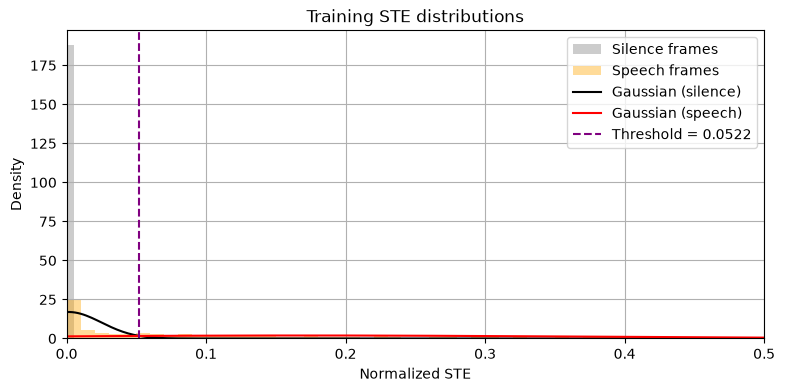

[OPTIMAL THRESHOLD] T1 (STE) = 0.05221  (intersection of the two Gaussians)


In [12]:
# Distribution figure (silence vs speech)
plot_training_distributions(model)

# Learned threshold
print(f"[OPTIMAL THRESHOLD] T1 (STE) = {model['threshold']:.5f}  (intersection of the two Gaussians)")

#### Comment on Figure 1 — training distributions and threshold
Training files: `<list the training files>`.

- **Fit of the Gaussians.** `<How well do the two Gaussians follow the histograms? Is the speech STE strongly skewed, so a Gaussian is only a rough model?>`
- **Overlap and threshold.** `<How much do the two classes overlap, and where does the threshold lie (value and position relative to the silence / speech peaks)?>`
- **Consequence.** `<What does this overlap imply for the test errors, e.g. weak unvoiced sounds at word edges being labelled as silence?>`

### 9.3 Testing (Figures 2–5)
Each test file is processed in its own cell and followed by a comment on its figure. In every figure the top panel shows the normalized signal, STE and the threshold, and the bottom panel shows the signal with the ground-truth boundaries (red) and the detected boundaries (blue). All errors are in milliseconds and, because the frame shift is 10 ms, they are always multiples of 10 ms.

In [13]:
print("--- STARTING TESTING PHASE ---")
print(f"Testing folder: {TEST_DIR}\n")

# file name -> (file name, #true bounds, #pred bounds, MAE, RMSE); filled by the cells below
results = {}

--- STARTING TESTING PHASE ---
Testing folder: TinHieuKiemThu



#### 9.3.1 `phone_F2.wav` (Figure 2)

=== phone_F2.wav ===
  truth    : [[1.02, 4.04]]
  predicted: [[1.09, 2.49], [2.8, 3.44], [3.67, 3.99]]
  #true = 2, #predicted = 6
  speech start at  1.020s -> predicted  1.090s, error   +70.0 ms [LARGE]
  speech end   at  4.040s -> predicted  3.990s, error   -50.0 ms [ok]


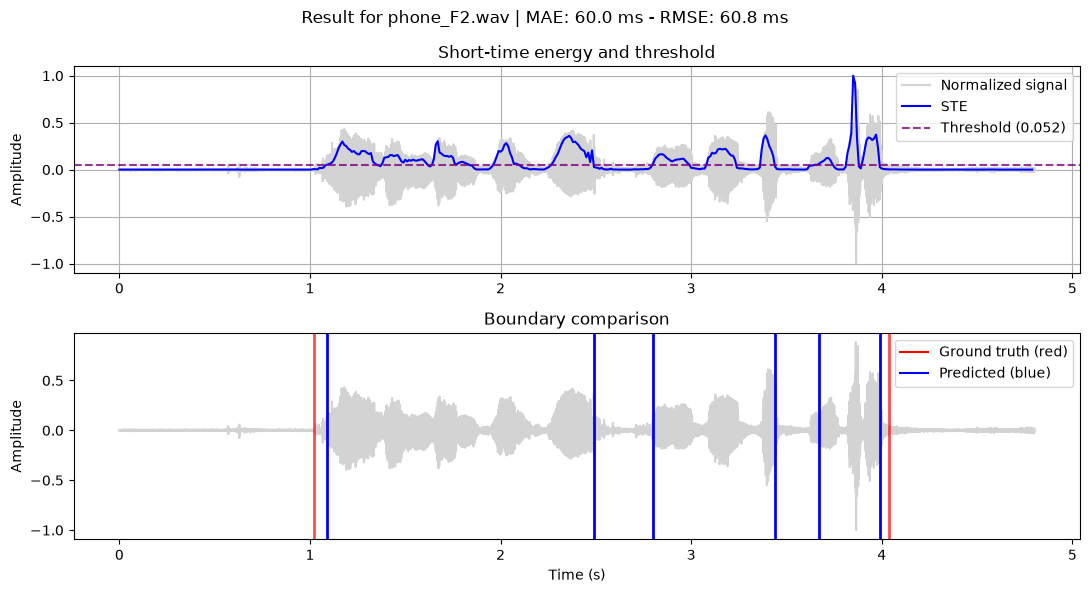

In [14]:
results["phone_F2.wav"] = test_file(model, os.path.join(TEST_DIR, "phone_F2.wav"))

#### Comment on Figure 2 — `phone_F2.wav` (MAE = `<x>` ms, RMSE = `<y>` ms)
- **Verdict: `<correct / partly wrong>`, `<small / large>` error.** `<How many boundaries are found, missing or extra (#true vs #predicted)?>`
- **Error size and place.** `<Which boundary (start / end) is wrong, at which time (s) on the figure, early or late and by how many ms?>`
- **Why.** `<Cause of the error, e.g. a weak onset / fade-out whose STE stays below the threshold, background noise above the threshold, a pause shorter than 200 ms that was filled.>`
- **Also visible.** `<Other observations on the figure: STE shape at the onset / offset, internal pauses, energy bursts.>`

#### 9.3.2 `phone_M2.wav` (Figure 3)

=== phone_M2.wav ===
  truth    : [[0.53, 2.52]]
  predicted: [[0.53, 1.46], [1.67, 2.49]]
  #true = 2, #predicted = 4
  speech start at  0.530s -> predicted  0.530s, error    +0.0 ms [ok]
  speech end   at  2.520s -> predicted  2.490s, error   -30.0 ms [ok]


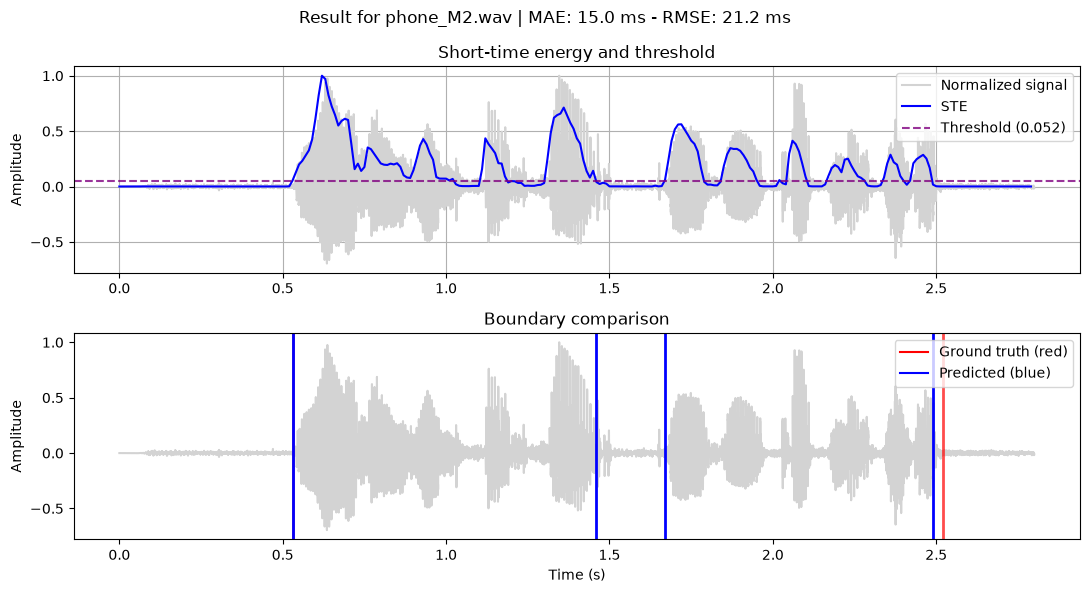

In [15]:
results["phone_M2.wav"] = test_file(model, os.path.join(TEST_DIR, "phone_M2.wav"))

#### Comment on Figure 3 — `phone_M2.wav` (MAE = `<x>` ms, RMSE = `<y>` ms)
- **Verdict: `<correct / partly wrong>`, `<small / large>` error.** `<How many boundaries are found, missing or extra (#true vs #predicted)?>`
- **Error size and place.** `<Which boundary (start / end) is wrong, at which time (s) on the figure, early or late and by how many ms?>`
- **Why.** `<Cause of the error, e.g. a weak onset / fade-out whose STE stays below the threshold, background noise above the threshold, a pause shorter than 200 ms that was filled.>`
- **Also visible.** `<Other observations on the figure: STE shape at the onset / offset, internal pauses, energy bursts.>`

#### 9.3.3 `studio_F2.wav` (Figure 4)

=== studio_F2.wav ===
  truth    : [[0.77, 2.37]]
  predicted: [[0.77, 2.29]]
  #true = 2, #predicted = 2
  speech start at  0.770s -> predicted  0.770s, error    +0.0 ms [ok]
  speech end   at  2.370s -> predicted  2.290s, error   -80.0 ms [LARGE]


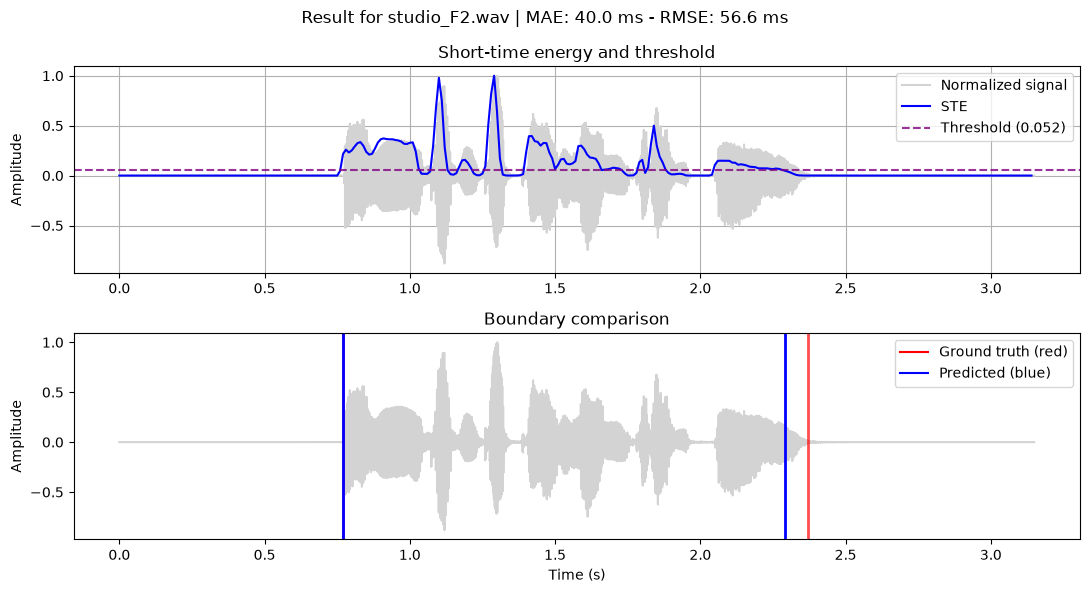

In [16]:
results["studio_F2.wav"] = test_file(model, os.path.join(TEST_DIR, "studio_F2.wav"))

#### Comment on Figure 4 — `studio_F2.wav` (MAE = `<x>` ms, RMSE = `<y>` ms)
- **Verdict: `<correct / partly wrong>`, `<small / large>` error.** `<How many boundaries are found, missing or extra (#true vs #predicted)?>`
- **Error size and place.** `<Which boundary (start / end) is wrong, at which time (s) on the figure, early or late and by how many ms?>`
- **Why.** `<Cause of the error, e.g. a weak onset / fade-out whose STE stays below the threshold, background noise above the threshold, a pause shorter than 200 ms that was filled.>`
- **Also visible.** `<Other observations on the figure: STE shape at the onset / offset, internal pauses, energy bursts.>`

#### 9.3.4 `studio_M2.wav` (Figure 5)

=== studio_M2.wav ===
  truth    : [[0.45, 1.93]]
  predicted: [[0.47, 1.88]]
  #true = 2, #predicted = 2
  speech start at  0.450s -> predicted  0.470s, error   +20.0 ms [ok]
  speech end   at  1.930s -> predicted  1.880s, error   -50.0 ms [LARGE]


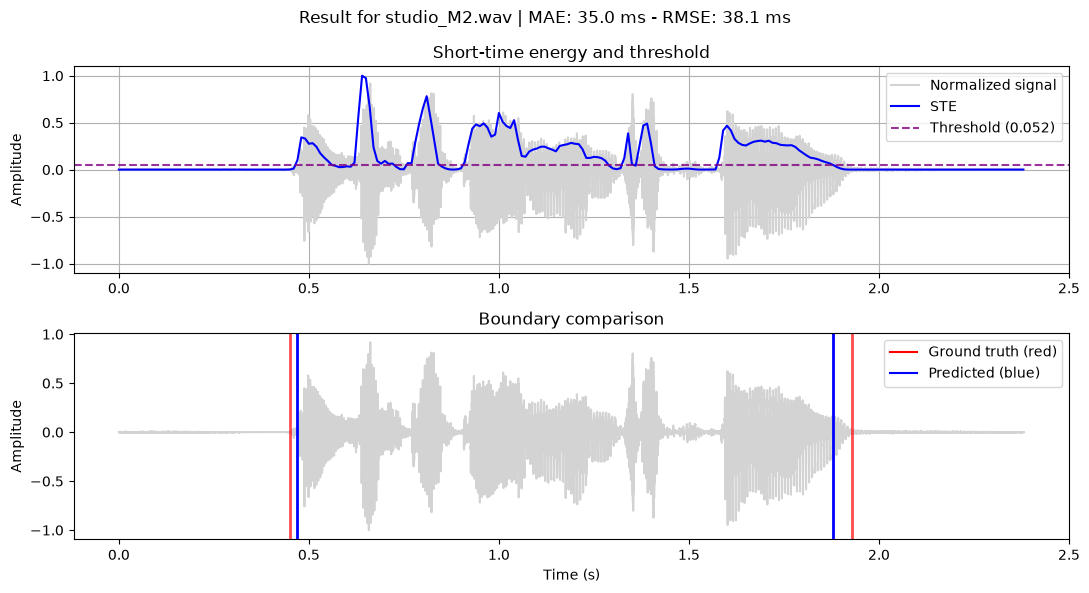

In [17]:
results["studio_M2.wav"] = test_file(model, os.path.join(TEST_DIR, "studio_M2.wav"))

#### Comment on Figure 5 — `studio_M2.wav` (MAE = `<x>` ms, RMSE = `<y>` ms)
- **Verdict: `<correct / partly wrong>`, `<small / large>` error.** `<How many boundaries are found, missing or extra (#true vs #predicted)?>`
- **Error size and place.** `<Which boundary (start / end) is wrong, at which time (s) on the figure, early or late and by how many ms?>`
- **Why.** `<Cause of the error, e.g. a weak onset / fade-out whose STE stays below the threshold, background noise above the threshold, a pause shorter than 200 ms that was filled.>`
- **Also visible.** `<Other observations on the figure: STE shape at the onset / offset, internal pauses, energy bursts.>`

### 9.4 Summary table
MAE / RMSE of each test file and their average — the numbers to report in the comparison table of the slides.

In [18]:
print_test_summary(list(results.values()))

[TEST]
File              #true   #pred   MAE(ms)  RMSE(ms)
phone_F2.wav          2       6     60.00     60.83
phone_M2.wav          2       4     15.00     21.21
studio_F2.wav         2       2     40.00     56.57
studio_M2.wav         2       2     35.00     38.08
AVERAGE                             37.50     44.17


#### Overall conclusion
- **Result.** `<Average MAE / RMSE and which files are best / worst.>`
- **Limitations.** `<Why a single STE threshold is limited, e.g. weak unvoiced sounds and noisy recordings.>`
- **Improvement.** `<One possible improvement, e.g. adding ZCR for weak unvoiced sounds or an adaptive threshold.>`